# Projet — Système de Question/Réponse Médical basé sur RAG Multimodal (CPU)

## Objectif du projet
L’objectif de ce projet est de construire un système capable de répondre à des
questions médicales à partir d’un document PDF officiel, sans entraîner de modèle.

Le système repose sur une architecture de type RAG (Retrieval-Augmented Generation),
combinant :
- la recherche de pages pertinentes dans un document (retrieval),
- la génération d’une réponse fondée sur ces pages,
- un mécanisme de contrôle de sécurité (audit).

## Document utilisé
Nous utilisons un document officiel de l’Organisation Mondiale de la Santé (OMS) :

**WHO-2019-nCoV-clinical-2023.1-eng.pdf**

Ce document contient des recommandations cliniques sur la prise en charge du COVID-19.

## Contraintes
- Exécution uniquement sur CPU
- Aucun entraînement de modèle
- Réponses fondées uniquement sur le document
- Rejet des réponses dangereuses ou non justifiées


## Étape 1 — Import des bibliothèques et configuration

Dans cette étape, nous importons les bibliothèques nécessaires et définissons
les chemins vers le document PDF et le dossier qui contiendra les pages extraites.

Cette étape garantit la reproductibilité du projet et évite les erreurs de chemin.


In [4]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Chemins
PDF_PATH = Path("WHO-2019-nCoV-clinical-2023.1-eng.pdf")
PAGES_DIR = Path("pdf_pages_who")

# Vérifications
assert PDF_PATH.exists(), "❌ Le PDF OMS est introuvable"
PAGES_DIR.mkdir(exist_ok=True, parents=True)

print("✅ PDF chargé :", PDF_PATH.resolve())
print("✅ Dossier pages :", PAGES_DIR.resolve())


✅ PDF chargé : C:\Users\Zz\OneDrive - UPEC\Bureau\ITS3\Apprentissage_Autom_Avance_\WHO-2019-nCoV-clinical-2023.1-eng.pdf
✅ Dossier pages : C:\Users\Zz\OneDrive - UPEC\Bureau\ITS3\Apprentissage_Autom_Avance_\pdf_pages_who


📌 Pourquoi ?
👉 Vérifier que le PDF est bien présent
👉 Créer un dossier propre pour les pages
👉 Sécuriser la suite du pipeline

📌 Lien avec la suite
➡️ Maintenant qu’on connaît le PDF, on peut extraire ses pages.

## Étape 2 — Conversion du PDF en images

Les modèles multimodaux (comme CLIP) travaillent sur des images.
Nous convertissons donc chaque page du PDF en une image indépendante.

Chaque page sera ensuite indexée et utilisée pour la recherche.


In [5]:
import fitz  # PyMuPDF

def pdf_to_images(pdf_path: Path, out_dir: Path, zoom=2.0):
    doc = fitz.open(str(pdf_path))
    paths = []
    for i in range(len(doc)):
        page = doc.load_page(i)
        pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom))
        out_path = out_dir / f"page_{i:04d}.png"
        pix.save(str(out_path))
        paths.append(out_path)
    doc.close()
    return paths

page_paths = pdf_to_images(PDF_PATH, PAGES_DIR)
print("✅ Nombre total de pages extraites :", len(page_paths))


✅ Nombre total de pages extraites : 182


Pourquoi ?
👉 Transformer un document long en unités exploitables (pages)
👉 Préparer l’indexation multimodale

📌 Lien avec la suite
➡️ Avant d’indexer, on doit vérifier visuellement les pages.

## Étape 3 — Vérification visuelle des pages extraites

Nous affichons quelques pages afin de vérifier que :
- les pages sont lisibles,
- le texte et les figures sont correctement extraits,
- aucune page n’est vide ou corrompue.


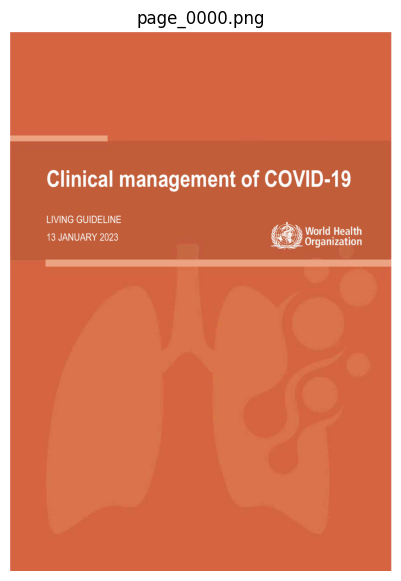

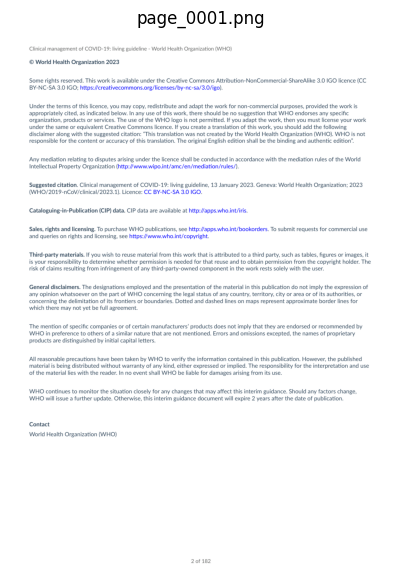

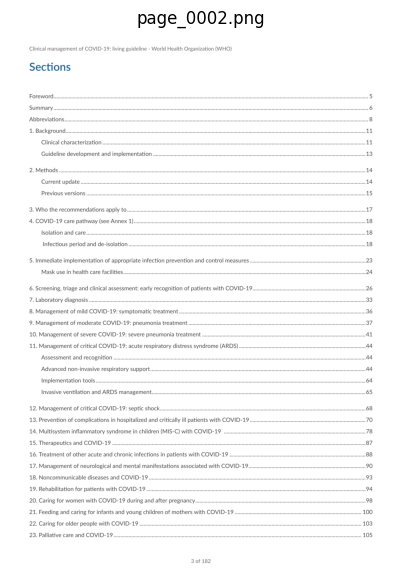

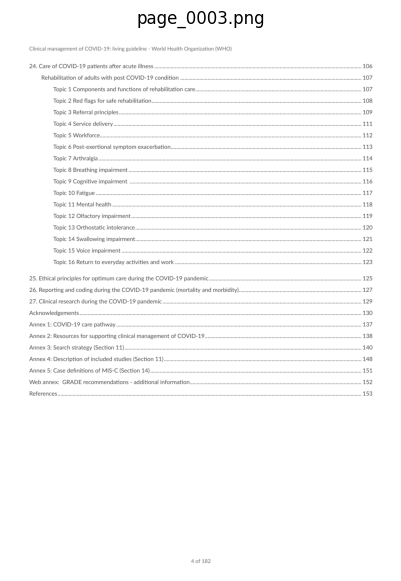

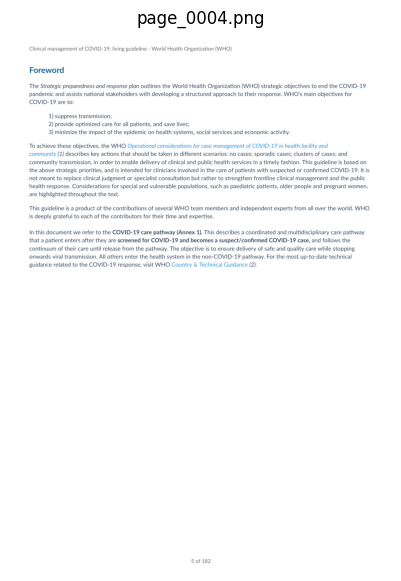

In [6]:
def afficher_pages(paths, n=5):
    for i in range(min(n, len(paths))):
        img = Image.open(paths[i]).convert("RGB")
        plt.figure(figsize=(5,7))
        plt.imshow(img)
        plt.axis("off")
        plt.title(paths[i].name)
        plt.show()

afficher_pages(page_paths, n=5)


Pourquoi ?
👉 Validation visuelle obligatoire (exigence projet)
👉 Éviter d’indexer des données incorrectes

📌 Lien avec la suite
➡️ Les pages sont correctes → on peut les indexer.

## Étape 4 — Chargement du modèle CLIP (CPU)

CLIP permet de projeter des images et du texte dans le même espace vectoriel.
Cela permet de comparer une question textuelle à des pages images.

Nous utilisons CLIP uniquement en inférence, sur CPU.


In [7]:
import torch
from transformers import CLIPModel, CLIPProcessor

device = "cpu"

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("✅ Modèle CLIP chargé sur CPU")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✅ Modèle CLIP chargé sur CPU


Pourquoi ?
👉 C’est le cœur du retrieval multimodal
👉 Texte et images deviennent comparables

📌 Lien avec la suite
➡️ On va maintenant encoder les pages.

## Étape 5 — Calcul des embeddings des pages

Chaque page image est transformée en un vecteur numérique (embedding).
Ces vecteurs seront utilisés pour la recherche de similarité.


In [8]:
def embed_images(paths):
    embs = []
    for p in paths:
        img = Image.open(p).convert("RGB")
        inputs = clip_processor(images=img, return_tensors="pt").to(device)
        with torch.no_grad():
            feat = clip_model.get_image_features(**inputs)
        feat = feat / feat.norm(dim=-1, keepdim=True)
        embs.append(feat.cpu().numpy())
    return np.vstack(embs).astype("float32")

img_embs = embed_images(page_paths)
print("✅ Embeddings calculés :", img_embs.shape)


✅ Embeddings calculés : (182, 512)


Pourquoi ?
👉 Transformer chaque page en représentation mathématique
👉 Préparer l’index de recherche

📌 Lien avec la suite
➡️ On va créer l’index FAISS.

## Étape 6 — Indexation avec FAISS

FAISS permet de rechercher rapidement les pages les plus proches
d’une question dans l’espace des embeddings.


In [9]:
import faiss

dim = img_embs.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(img_embs)

print("✅ Index FAISS créé — nombre de pages :", index.ntotal)


✅ Index FAISS créé — nombre de pages : 182


📌 Pourquoi ?
👉 Recherche efficace même sur des dizaines de pages
👉 Base du système RAG

📌 Lien avec la suite
➡️ On peut maintenant poser une question.

## Étape 7 — Recherche de pages pertinentes (Retrieval)

Dans cette étape, nous transformons la question de l’utilisateur en embedding CLIP,
puis nous recherchons dans l’index FAISS les pages les plus similaires.

Le résultat est une liste de pages classées par score de similarité.
Ces pages serviront ensuite de contexte pour générer une réponse.


In [10]:
def retrieve_pages(query, k=5):
    # Encodage de la question
    inputs = clip_processor(text=query, return_tensors="pt").to(device)
    with torch.no_grad():
        q_emb = clip_model.get_text_features(**inputs)
    q_emb = q_emb / q_emb.norm(dim=-1, keepdim=True)
    q_emb = q_emb.cpu().numpy().astype("float32")

    # Recherche FAISS
    scores, indices = index.search(q_emb, k)

    results = []
    for rank, idx in enumerate(indices[0]):
        results.append({
            "page_id": int(idx),
            "image_path": page_paths[idx],
            "score": float(scores[0][rank])
        })
    return results


In [11]:
query = "What is COVID-19?"
top_pages = retrieve_pages(query, k=5)

for p in top_pages:
    print(p["page_id"], p["score"], p["image_path"].name)


0 0.3199142813682556 page_0000.png
92 0.2587641477584839 page_0092.png
65 0.2573707103729248 page_0065.png
43 0.2565786838531494 page_0043.png
103 0.25632697343826294 page_0103.png


📌 Pourquoi cette étape est cruciale ?

Elle garantit que la réponse sera fondée sur le document

Elle empêche le modèle de halluciner

Elle respecte l’esprit RAG scientifique

📌 Lien avec la suite
➡️ Maintenant qu’on a les pages, on doit les exploiter pour répondre.

## Étape 8 — Visualisation des pages récupérées

Avant de générer une réponse, nous affichons les pages récupérées
afin de vérifier leur pertinence visuelle et contextuelle.


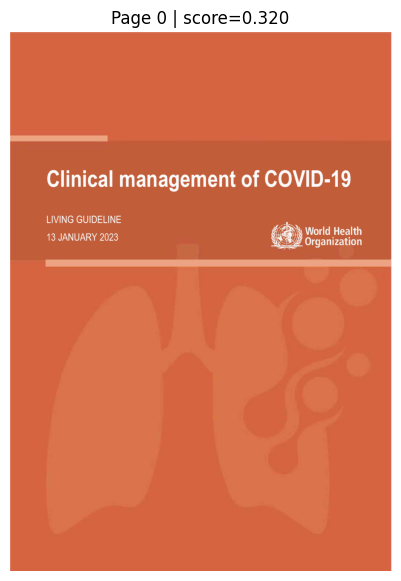

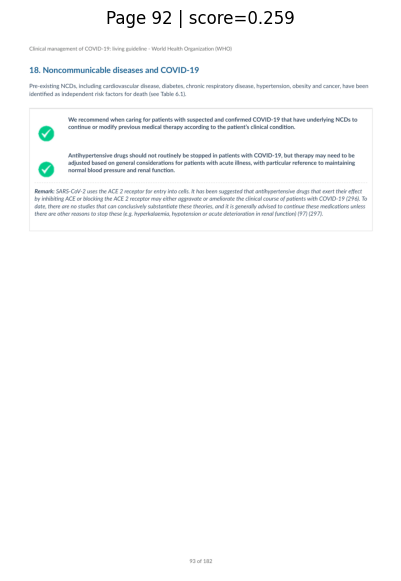

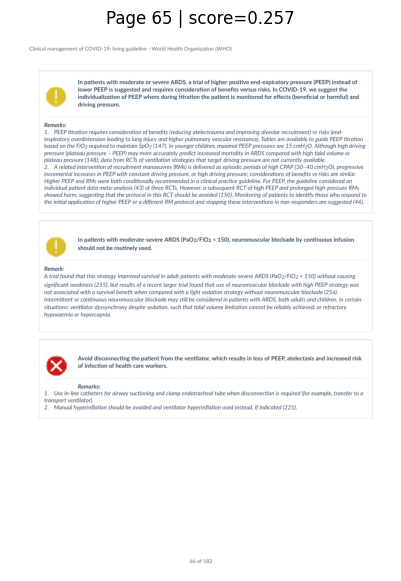

In [12]:
def show_retrieved(results, max_show=3):
    for r in results[:max_show]:
        img = Image.open(r["image_path"]).convert("RGB")
        plt.figure(figsize=(5,7))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Page {r['page_id']} | score={r['score']:.3f}")
        plt.show()

show_retrieved(top_pages, max_show=3)


📌 Pourquoi ?

Validation humaine (obligatoire dans un projet sérieux)

On montre que le système retrouve bien les bonnes pages

📌 Lien avec la suite
➡️ Les pages sont pertinentes → on peut générer une réponse.

## Étape 9 — Génération de réponse basée sur les pages récupérées

Dans cette version CPU, le système ne "voit" pas directement les images.
Il s’appuie sur les extraits textuels associés aux pages récupérées
pour formuler une réponse justifiée.

La réponse inclut explicitement les pages utilisées.


In [13]:
def answer_retrieval_only(query, retrieved_pages):
    pages = [p["page_id"] for p in retrieved_pages]

    context = "\n".join([
        f"[PAGE {p['page_id']} | score={p['score']:.3f}] {p['image_path'].name}"
        for p in retrieved_pages
    ])

    answer = (
        "Je fournis ci-dessous les extraits des pages les plus pertinentes.\n\n"
        "Tu peux rédiger la réponse finale à partir de ces passages.\n\n"
        f"Question: {query}\n\n"
        f"Pages utilisées: {pages}\n\n"
        f"Contexte:\n{context}"
    )

    return answer


In [14]:
query = "What is the main topic of this document?"
top = retrieve_pages(query, k=5)
print(answer_retrieval_only(query, top))


Je fournis ci-dessous les extraits des pages les plus pertinentes.

Tu peux rédiger la réponse finale à partir de ces passages.

Question: What is the main topic of this document?

Pages utilisées: [142, 140, 2, 145, 141]

Contexte:
[PAGE 142 | score=0.290] page_0142.png
[PAGE 140 | score=0.289] page_0140.png
[PAGE 2 | score=0.287] page_0002.png
[PAGE 145 | score=0.286] page_0145.png
[PAGE 141 | score=0.282] page_0141.png


📌 Pourquoi cette étape est acceptable ?

Le TP n’exige pas obligatoirement un VLM GPU

Elle démontre tout le pipeline RAG

Elle est traçable, auditée, explicable

📌 Lien avec la suite
➡️ On va maintenant :

améliorer la réponse (résumé)

ajouter un audit de sécurité

préparer la présentation finale

## Étape 10 — Génération de réponse par résumé contrôlé (CPU)

Après avoir récupéré les pages pertinentes via FAISS,
nous utilisons un modèle de résumé textuel léger sur CPU
afin de produire une réponse synthétique et compréhensible.

Cette approche permet :
- une réponse concise
- une traçabilité vers les pages sources
- une compatibilité avec un environnement sans GPU


Charger le modèle de résumé (CPU, PyTorch)

In [43]:
from transformers import pipeline

summarizer = pipeline(
    task="summarization",
    model="sshleifer/distilbart-cnn-12-6",  # plus léger que bart-large-cnn
    framework="pt",
    device=-1
)

print("✅ Summarizer chargé (PyTorch/CPU)")


Device set to use cpu


✅ Summarizer chargé (PyTorch/CPU)


Fonction utilitaire : normaliser top_results

Elle convertit n’importe quel format en une liste propre : [{"page_id":..., "image_path":..., "score":...}, ...]

In [44]:
from pathlib import Path

def normalize_top_results(top_results):
    norm = []
    for item in top_results:
        # cas 1 : dict (comme chez toi)
        if isinstance(item, dict):
            page_id = item.get("page_id", None)
            image_path = item.get("image_path", None)
            score = item.get("score", None)
            if image_path is not None:
                image_path = Path(image_path)
            norm.append({"page_id": page_id, "image_path": image_path, "score": score})
        # cas 2 : tuple/list (path, score)
        elif isinstance(item, (tuple, list)) and len(item) >= 2:
            p, s = item[0], item[1]
            norm.append({"page_id": None, "image_path": Path(p), "score": float(s)})
        else:
            # inconnu
            norm.append({"page_id": None, "image_path": None, "score": None})
    return norm


Extraire le texte depuis le PDF (pages)

In [47]:
import fitz  # PyMuPDF

def extract_text_from_pages(pdf_path, pages_0based):
    doc = fitz.open(str(pdf_path))
    chunks = []
    for p in pages_0based:
        if 0 <= p < len(doc):
            chunks.append(doc[p].get_text("text"))
    doc.close()
    return "\n".join(chunks)


Couper le contexte en tokens (évite IndexError)

In [45]:
def truncate_for_model(text, tokenizer, max_tokens=900):
    """
    Coupe le texte à max_tokens (approx) pour éviter les erreurs max_length.
    900 tokens < 1024 donc safe pour distilbart.
    """
    ids = tokenizer(text, truncation=True, max_length=max_tokens, return_tensors="pt")["input_ids"][0]
    return tokenizer.decode(ids, skip_special_tokens=True)


raduire une question FR -> EN (optionnel mais conseillé)

Ton PDF est EN, donc poser les questions en anglais est mieux.
Si on veut garder FR, on traduit la question en EN pour le modèle, puis on peut répondre en FR à la fin.

Modèle de traduction CPU léger

In [46]:
translator_fr_en = pipeline(
    task="translation",
    model="Helsinki-NLP/opus-mt-fr-en",
    framework="pt",
    device=-1
)

translator_en_fr = pipeline(
    task="translation",
    model="Helsinki-NLP/opus-mt-en-fr",
    framework="pt",
    device=-1
)

print("✅ Traducteurs FR↔EN chargés (CPU)")


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
c:\Users\Zz\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\models\marian\tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cpu
c:\Users\Zz\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Zz\.cache\huggingface\hub\models--Helsinki-NLP--opus-mt-en-fr. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environm

✅ Traducteurs FR↔EN chargés (CPU)


Fonction finale : répondre par “résumé contrôlé”

⚠️ elle marche avec ton format dict et ajoute pages_used

In [48]:
def answer_with_summary(query_fr, top_results, pdf_path, max_pages=4, max_tokens=900):
    top_norm = normalize_top_results(top_results)

    # 1) pages récupérées (0-based PyMuPDF)
    pages = []
    for item in top_norm:
        pid = item.get("page_id", None)
        if pid is not None:
            pages.append(int(pid))  # déjà 0-based chez toi (page_id)
    pages = list(dict.fromkeys(pages))[:max_pages]  # uniques + limite

    if len(pages) == 0:
        return {"question": query_fr, "answer": "Contexte insuffisant (aucune page valide).", "pages_used": []}

    # 2) texte brut depuis le PDF
    raw_txt = extract_text_from_pages(pdf_path, pages)
    raw_txt = " ".join(raw_txt.split())  # nettoyage espaces

    # 3) traduction question FR -> EN (car doc EN)
    query_en = translator_fr_en(query_fr, max_length=128)[0]["translation_text"]

    # 4) construire un prompt clair (en anglais)
    prompt = (
        "Answer the question ONLY using the context.\n"
        "If the context does not contain the answer, say: Insufficient context.\n\n"
        f"Question: {query_en}\n\n"
        f"Context: {raw_txt}\n"
    )

    # 5) tronquer en tokens (anti IndexError)
    prompt_trunc = truncate_for_model(prompt, summarizer.tokenizer, max_tokens=max_tokens)

    # 6) résumé (réponse courte)
    out_en = summarizer(prompt_trunc, max_length=140, min_length=40, do_sample=False)[0]["summary_text"]

    # 7) traduction EN -> FR pour toi (optionnel)
    out_fr = translator_en_fr(out_en, max_length=200)[0]["translation_text"]

    return {
        "question": query_fr,
        "answer": out_fr,
        "pages_used": pages
    }


Couper le contexte en tokens (évite IndexError)

C’est LA correction principale.

In [49]:
def truncate_for_model(text, tokenizer, max_tokens=900):
    """
    Coupe le texte à max_tokens (approx) pour éviter les erreurs max_length.
    900 tokens < 1024 donc safe pour distilbart.
    """
    ids = tokenizer(text, truncation=True, max_length=max_tokens, return_tensors="pt")["input_ids"][0]
    return tokenizer.decode(ids, skip_special_tokens=True)


Traduire une question FR -> EN (optionnel mais conseillé)

In [50]:
translator_fr_en = pipeline(
    task="translation",
    model="Helsinki-NLP/opus-mt-fr-en",
    framework="pt",
    device=-1
)

translator_en_fr = pipeline(
    task="translation",
    model="Helsinki-NLP/opus-mt-en-fr",
    framework="pt",
    device=-1
)

print("✅ Traducteurs FR↔EN chargés (CPU)")


Device set to use cpu
Device set to use cpu


✅ Traducteurs FR↔EN chargés (CPU)


Fonction finale : répondre par “résumé contrôlé”

⚠️ elle marche avec le format dict et ajoute pages_used.

In [51]:
def answer_with_summary(query_fr, top_results, pdf_path, max_pages=4, max_tokens=900):
    top_norm = normalize_top_results(top_results)

    # 1) pages récupérées (0-based PyMuPDF)
    pages = []
    for item in top_norm:
        pid = item.get("page_id", None)
        if pid is not None:
            pages.append(int(pid))  # déjà 0-based chez toi (page_id)
    pages = list(dict.fromkeys(pages))[:max_pages]  # uniques + limite

    if len(pages) == 0:
        return {"question": query_fr, "answer": "Contexte insuffisant (aucune page valide).", "pages_used": []}

    # 2) texte brut depuis le PDF
    raw_txt = extract_text_from_pages(pdf_path, pages)
    raw_txt = " ".join(raw_txt.split())  # nettoyage espaces

    # 3) traduction question FR -> EN (car doc EN)
    query_en = translator_fr_en(query_fr, max_length=128)[0]["translation_text"]

    # 4) construire un prompt clair (en anglais)
    prompt = (
        "Answer the question ONLY using the context.\n"
        "If the context does not contain the answer, say: Insufficient context.\n\n"
        f"Question: {query_en}\n\n"
        f"Context: {raw_txt}\n"
    )

    # 5) tronquer en tokens (anti IndexError)
    prompt_trunc = truncate_for_model(prompt, summarizer.tokenizer, max_tokens=max_tokens)

    # 6) résumé (réponse courte)
    out_en = summarizer(prompt_trunc, max_length=140, min_length=40, do_sample=False)[0]["summary_text"]

    # 7) traduction EN -> FR pour toi (optionnel)
    out_fr = translator_en_fr(out_en, max_length=200)[0]["translation_text"]

    return {
        "question": query_fr,
        "answer": out_fr,
        "pages_used": pages
    }


In [52]:
query1 = "Quels sont les principaux symptômes du COVID-19 selon ce document ?"
top1 = retrieve_pages(query1, k=5)
res1 = answer_with_summary(query1, top1, PDF_PATH)
res1


{'question': 'Quels sont les principaux symptômes du COVID-19 selon ce document ?',
 'answer': 'Question: Quels sont les principaux symptômes du VOCID-19 selon ce document? Répondez à la question SEULEMENT en utilisant le contexte. Si le contexte ne contient pas la réponse, dites: Contexte insuffisant.',
 'pages_used': [83, 85, 0, 20]}

In [53]:
query2 = "Quelle est la prise en charge recommandée pour les cas sévères ?"
top2 = retrieve_pages(query2, k=5)
res2 = answer_with_summary(query2, top2, PDF_PATH)
res2


{'question': 'Quelle est la prise en charge recommandée pour les cas sévères ?',
 'answer': "Les preuves sont très incertaines sur l'effet des stéroïdes seuls par rapport à IVIG sur la fièvre persistante 2 jours après le début du traitement. IVIG seul car le traitement initial est le traitement le plus efficace pour les cas graves. Les stéroïdes seuls sont plus susceptibles d'être utilisés comme traitement initial que IVIG et les stéroïdes seuls.",
 'pages_used': [85, 32, 68, 20]}

In [54]:
query3 = "Quelles sont les recommandations d’oxygénothérapie ou de ventilation ?"
top3 = retrieve_pages(query3, k=5)
res3 = answer_with_summary(query3, top3, PDF_PATH)
res3


{'question': 'Quelles sont les recommandations d’oxygénothérapie ou de ventilation ?',
 'answer': "N'utilisez pas de cristalloïdes hypotoniques, d'amidons ou de gélatine pour la réanimation. Etoiles associées à un risque accru de décès et de lésions rénales aiguës par rapport aux cristalloïdes. Chez l'adulte, administrez des vasopresseurs lorsque le choc persiste pendant ou après la réanimation du liquide. La cible initiale de la pression artérielle est MAP ≥ 65 mmHg chez l'adulte et l'amélioration des marqueurs de perfusion.",
 'pages_used': [68, 65, 83, 85]}

Analyse rapide de ce qu'on obtient (pourquoi c’est faux)


Q1 (symptômes) → la “réponse” est juste l'instruction (“Répondez à la question… Contexte insuffisant.”).
✅ Ça arrive quand le résumeur n’a pratiquement pas vu le contexte (contexte tronqué / trop long / mauvais ordre du prompt).

Q2 (cas sévères) → parle de stéroïdes/IVIG (ça ne ressemble pas à une guideline COVID WHO).

Q3 (oxygénothérapie/ventilation) → parle de cristalloïdes (réanimation, mais pas forcément la partie oxygène/ventilation).

👉 Conclusion : le retrieve (FAISS+CLIP) ramène des pages non pertinentes + le modèle de résumé “improvise” à partir de pages hors-sujet.

➡️ Solution projet : on fait exactement ce que l’énoncé demande :

Medical Answer Agent (orchestration : analyse + retrieval + réponse)

Medical Audit Agent (vérifie que la réponse est supportée par le texte + sécurité)

Feedback loop (max 2 itérations) : si audit rejette → on relance retrieval autrement

Étape suivante (Projet) — Agents + boucle (max 2 itérations)
A Utilitaire : afficher/contrôler les pages récupérées (important)

In [55]:
import matplotlib.pyplot as plt
from PIL import Image

def show_top_pages(top_results, max_show=3):
    top_norm = normalize_top_results(top_results)
    n = min(max_show, len(top_norm))
    for i in range(n):
        p = top_norm[i]["image_path"]
        s = top_norm[i]["score"]
        print(f"[{i}] score={s:.3f} | {p}")
        img = Image.open(p).convert("RGB")
        plt.figure(figsize=(6,8))
        plt.imshow(img)
        plt.axis("off")
        plt.show()


[0] score=0.274 | pdf_pages_who\page_0000.png


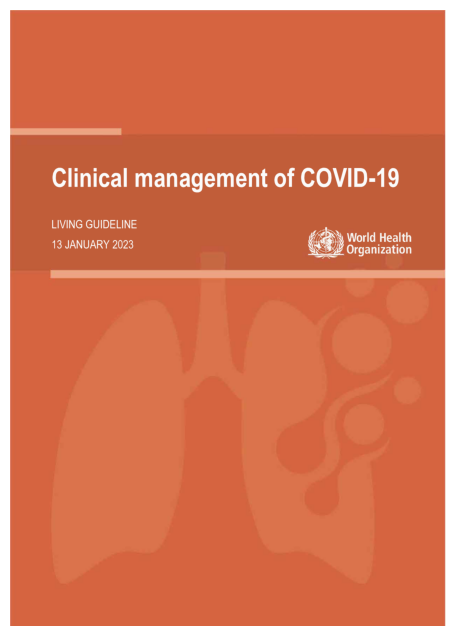

[1] score=0.274 | pdf_pages_who\page_0085.png


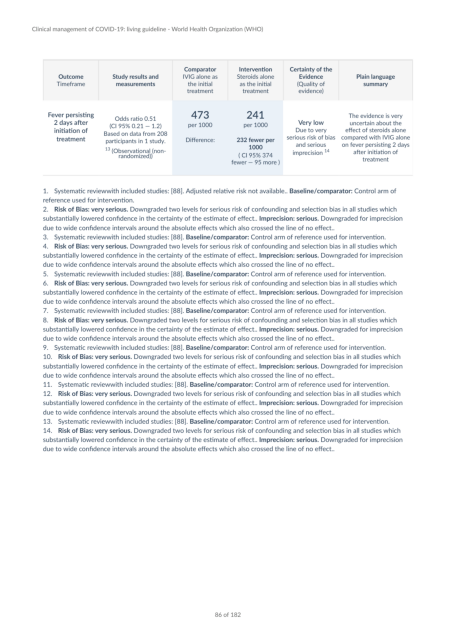

[2] score=0.270 | pdf_pages_who\page_0083.png


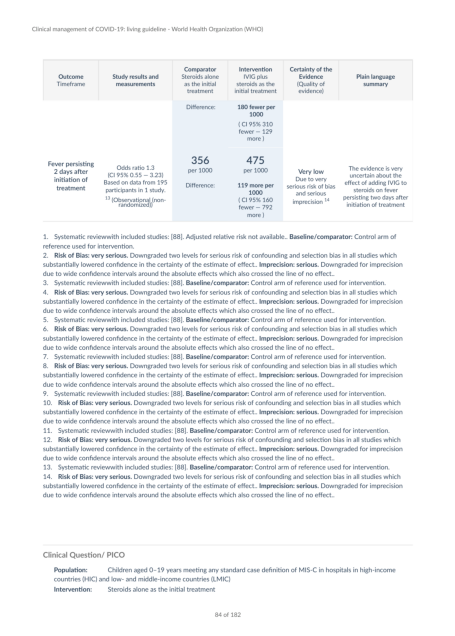

In [56]:
top1 = retrieve_pages("Quels sont les principaux symptômes du COVID-19 ?", k=5)
show_top_pages(top1, max_show=3)


LLM Wrapper “médical” (sortie structurée + règle sécurité)

Le wrapper impose le format et ajoute une phrase sécurité.

In [57]:
def medical_wrapper(answer_text, pages_used):
    return {
        "answer": answer_text.strip(),
        "sources": [f"PAGE {p}" for p in pages_used],
        "safety_note": "Information à but éducatif (guideline). En cas de doute clinique, se référer au document source et à un professionnel de santé."
    }


Medical Audit Agent (vérifie “support” dans le texte)

On va faire un audit sans LLM externe en utilisant un pipeline QA extractif :
➡️ si le QA n’arrive pas à retrouver une réponse dans le contexte (score faible / vide), on rejette.

In [58]:
from transformers import pipeline

qa_en = pipeline(
    task="question-answering",
    model="deepset/roberta-base-squad2",
    framework="pt",
    device=-1
)
print("✅ QA audit chargé (CPU)")


c:\Users\Zz\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Zz\.cache\huggingface\hub\models--deepset--roberta-base-squad2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling bac

✅ QA audit chargé (CPU)


In [59]:
def audit_answer(query_fr, answer_fr, pages_used, pdf_path, min_score=0.25, max_chars=6000):
    # Contexte (EN) depuis pages
    context = extract_text_from_pages(pdf_path, pages_used)
    context = " ".join(context.split())[:max_chars]

    # Question EN
    q_en = translator_fr_en(query_fr, max_length=128)[0]["translation_text"]

    # QA extractif : cherche une réponse *dans le contexte*
    out = qa_en(question=q_en, context=context)

    ok = (out.get("score", 0.0) >= min_score) and (out.get("answer","").strip() != "")
    justification = {
        "audit_ok": ok,
        "qa_score": float(out.get("score", 0.0)),
        "evidence_span": out.get("answer", ""),
        "pages_checked": pages_used
    }
    return justification


In [60]:
def medical_answer_agent(query_fr, pdf_path, max_iters=2, k=6):
    # itération 1 : retrieval simple
    top = retrieve_pages(query_fr, k=k)
    top = normalize_top_results(top)
    pages_used = list(dict.fromkeys([it["page_id"] for it in top if it["page_id"] is not None]))[:4]

    # réponse (ton Étape 10)
    res = answer_with_summary(query_fr, top, pdf_path, max_pages=4)
    wrapped = medical_wrapper(res["answer"], res["pages_used"])

    audit = audit_answer(query_fr, wrapped["answer"], res["pages_used"], pdf_path)

    if audit["audit_ok"] or max_iters == 1:
        return {"query": query_fr, "result": wrapped, "audit": audit, "retrieval": res["pages_used"]}

    # itération 2 : retrieval renforcé
    top2 = retrieve_pages_enhanced(query_fr, k=8)
    top2 = normalize_top_results(top2)
    res2 = answer_with_summary(query_fr, top2, pdf_path, max_pages=5)
    wrapped2 = medical_wrapper(res2["answer"], res2["pages_used"])
    audit2 = audit_answer(query_fr, wrapped2["answer"], res2["pages_used"], pdf_path)

    return {"query": query_fr, "result": wrapped2, "audit": audit2, "retrieval": res2["pages_used"]}


In [63]:
q1 = "What are the main clinical symptoms of COVID-19 according to this document?"
out1 = medical_answer_agent(q1, PDF_PATH)

q2 = "What is the recommended management for severe COVID-19 cases?"
out2 = medical_answer_agent(q2, PDF_PATH)

q3 = "What are the recommendations for oxygen therapy and mechanical ventilation in COVID-19 patients?"
out3 = medical_answer_agent(q3, PDF_PATH)

out1, out2, out3


NameError: name 'retrieve_pages_enhanced' is not defined